#Student Performance Prediction - Regression

## Predict Final Scores whit Machine Learning

În acest notebook abordăm o problemă de regresie pe un set de date educațional, în care obiectivul este să precizăm scorul final al studenților (`Final_Score`) pe baza unor factori academici, personali și sociali.

Vom analiza modul în care variabile precum timpul de studiu, prezența la cursuri, somnul, nivelul de stres, performanțele anterioare și stilul de viață influențează rezultatele finale ale studenților.

Vom parcurge întregul pipeline de machine learning:

- înțelegerea problemei
- analiza exploratorie a datelor
- preprocesare
- antrenarea și compararea modelelor
- ajustarea hiperparametrilor
- learning curves
- explicabilitate cu SHAP
- alegerea modelului final
- concluzii

# 1. Definirea problemei

Problema abordată este una de regresie: prezicerea scorului final obținut de un elev pe baza unor factori academici, personali și sociali.

### Variabila țintă
- `Final_Score` -> scorul final obținut de elev la evaluarea finală

### Variabile de intrare
Exemple de caracteristici utilizate:

- `Age`
- `Gender`
- `Hours_Studied`
- `Attendance`
- `Sleep_Hours`
- `Stress_Level`
- `Screen_Time`
- `Previous_GPA`
- `Part_Time_Job`
- `Study_Method`
- `Diet_Quality`
- `Internet_Quality`
- `Extracurricular`
- `Tutoring_Sessions_Per_Week`
- `Family_Income_Level`
- `Exam_Anxiety_Score`

### Relevanță practică

Această problemă este relevantă în domeniul educației, deoarece permite identificarea factorilor care influențează performanța elevilor și poate contribui la dezvoltarea unor strategii de sprijin academic personalizat.

### Motivația alegerii

Am ales această problemă deoarece combină un context real și actual cu o sarcină de regresie potrivită pentru compararea mai multor algoritmi de machine learning și pentru interpretarea impactului diferitelor variabile asupra rezultatelor finale.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from interpret.glassbox import ExplainableBoostingRegressor

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.gaussian_process import GaussianProcessRegressor

## 2. Analiza exploratorie a datelor și pregătirea lor

### Încărcarea datelor
În această secțiune încărcăm setul de date și verificăm dimensiunea și structura generală a acestuia.

In [2]:
df = pd.read_csv("../data/student_performance_finalscore.csv")
df.head()

,Student_ID,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
0,STU00001,17,Female,8.20,80.0,7.3,2.3,3.2,3.07,No,Online,Average,Average,Yes,3,High,1.8,87.10
1,STU00002,22,Male,4.07,69.2,7.9,3.6,0.5,2.66,Yes,Offline,Average,Good,No,2,Middle,1.0,92.03
2,STU00003,23,Female,5.07,74.2,6.7,2.6,4.7,3.27,No,Hybrid,Average,Good,No,1,Middle,4.2,95.37
3,STU00004,22,Female,5.82,82.5,3.7,3.3,2.3,2.87,No,Offline,Average,Excellent,No,0,Middle,3.6,90.73
4,STU00005,21,Male,3.42,90.8,7.4,7.0,3.1,2.82,Yes,Offline,Average,Good,No,2,Middle,4.5,74.71


In [3]:
df.shape

(8000, 18)

In [4]:
df.columns.tolist()

['Student_ID',
 'Age',
 'Gender',
 'Hours_Studied',
 'Attendance',
 'Sleep_Hours',
 'Stress_Level',
 'Screen_Time',
 'Previous_GPA',
 'Part_Time_Job',
 'Study_Method',
 'Diet_Quality',
 'Internet_Quality',
 'Extracurricular',
 'Tutoring_Sessions_Per_Week',
 'Family_Income_Level',
 'Exam_Anxiety_Score',
 'Final_Score']

### Explorarea structurii datelor
Verificăm tipurile de date, valorile lipsă, duplicatele și statistici descriptive.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  8000 non-null   str    
 1   Age                         8000 non-null   int64  
 2   Gender                      8000 non-null   str    
 3   Hours_Studied               8000 non-null   float64
 4   Attendance                  8000 non-null   float64
 5   Sleep_Hours                 8000 non-null   float64
 6   Stress_Level                8000 non-null   float64
 7   Screen_Time                 8000 non-null   float64
 8   Previous_GPA                8000 non-null   float64
 9   Part_Time_Job               8000 non-null   str    
 10  Study_Method                8000 non-null   str    
 11  Diet_Quality                8000 non-null   str    
 12  Internet_Quality            8000 non-null   str    
 13  Extracurricular             8000 non-null   

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,8000,8000,STU00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,8000.0,NaN,NaN,NaN,20.494375,2.285962,17.0,18.0,20.5,22.0,24.0
Gender,8000,3,Male,3906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hours_Studied,8000.0,NaN,NaN,NaN,4.983845,1.951715,0.02,3.68,4.98,6.3125,12.0
Attendance,8000.0,NaN,NaN,NaN,79.933375,9.656594,43.3,73.4,80.1,86.6,100.0
Sleep_Hours,8000.0,NaN,NaN,NaN,6.989125,1.192898,3.0,6.2,7.0,7.8,10.0
Stress_Level,8000.0,NaN,NaN,NaN,5.014175,1.940126,1.0,3.7,5.0,6.3,10.0
Screen_Time,8000.0,NaN,NaN,NaN,4.024525,1.481908,0.5,3.0,4.0,5.0,9.6
Previous_GPA,8000.0,NaN,NaN,NaN,2.992408,0.48953,1.5,2.67,2.99,3.33,6.7
Part_Time_Job,8000,2,No,4803,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Final_Score                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Observații asupra datelor

Setul de date conține 8000 de înregistrări și 18 coloane. Nu există valori lipsă și nici rânduri duplicate, ceea ce indică faptul că datele sunt curate.

Coloana `Student_ID` este un identificator unic și nu oferă informație predictivă, deci va fi eliminată înainte de antrenarea modelelor.

### Analiza exploratorie a datelor (EDA)
Începem prin analiza variabilei țintă `Final_Score`.

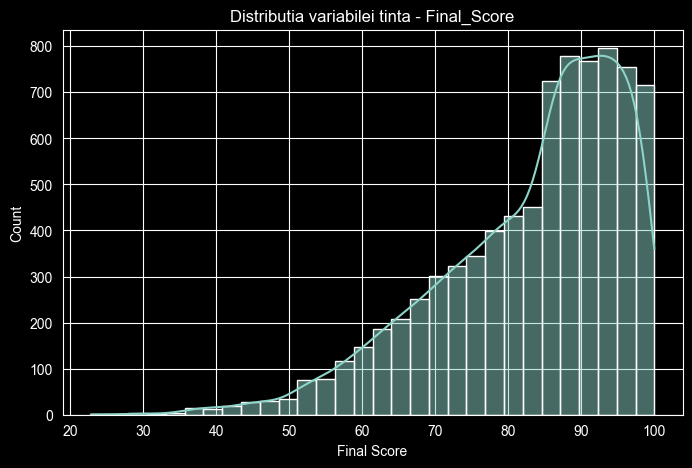

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Final_Score"], kde=True, bins=30)
plt.title("Distributia variabilei tinta - Final_Score")
plt.xlabel("Final Score")
plt.ylabel("Count")
plt.show()

## Interpretare

Distribuția variabilei țintă `Final_Score` arată că majoritatea studenților au scoruri ridicate, în special între aproximativ **80 și 100**.

Se observă o concentrație mare a valorilor în jurul scorurilor **90-95**, ceea ce sugerează că mulți studenți au performanțe bune sau foarte bune.

Distribuția nu este perfectă, fiind ușor asimetrică spre stânga, deoarece există mai puține scoruri mici și mai multe scoruri mari. Acest lucru poate influența modelele de regresie, deoarece acestea vor învăța mai bine zona în care există multe exemple și pot avea erori mai mari pentru scorurile foarte mici.

În concluzie, `Final_Score` este o variabilă numerică potrivită pentru regresie, iar distribuția sa trebuie avută în vedere la interpretarea performanței modelelor.

## Distribuția caracteristicilor numerice

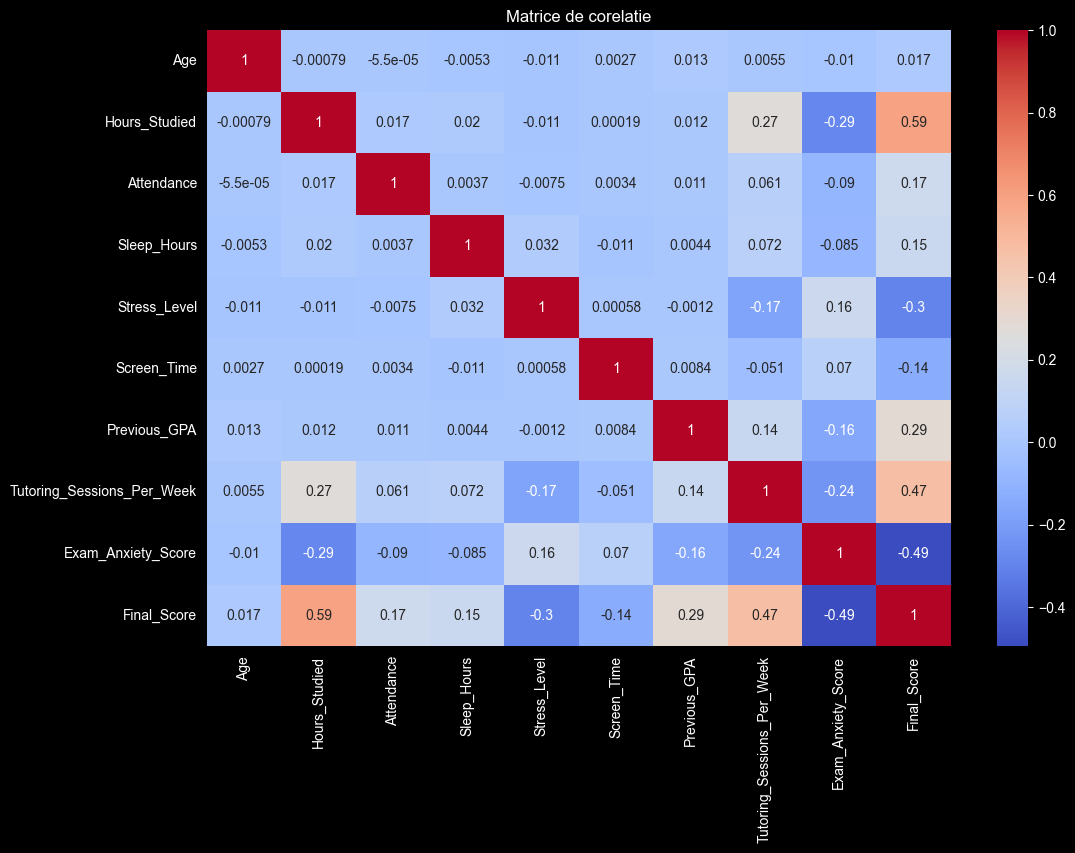

In [10]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corelatie")
plt.show()

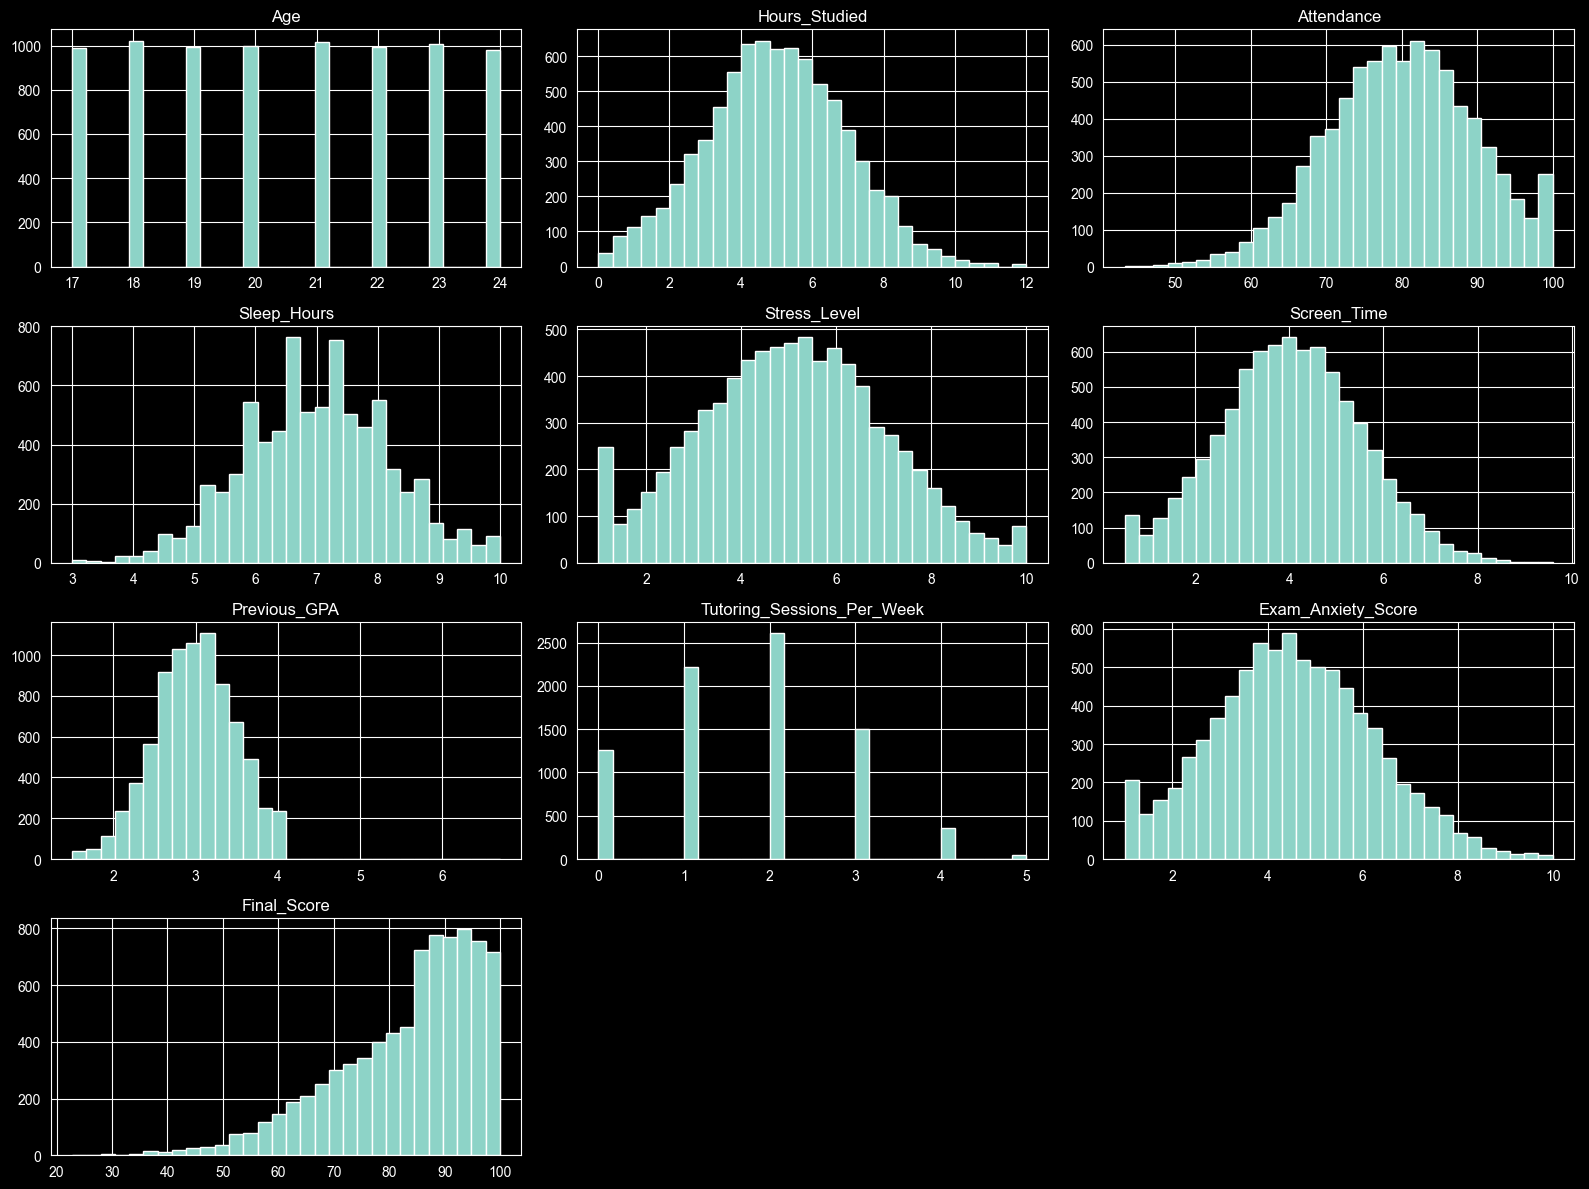

In [11]:
df[num_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

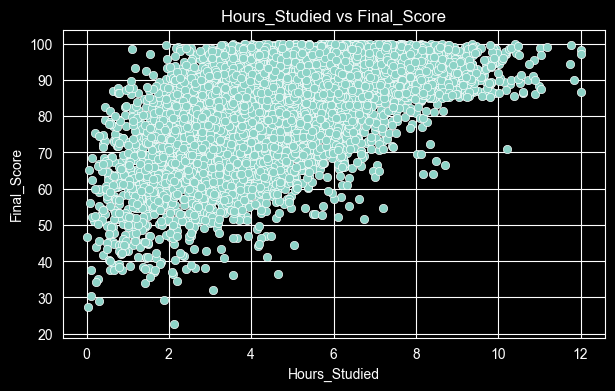

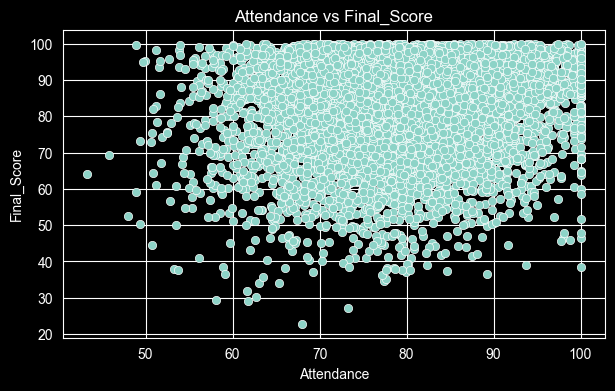

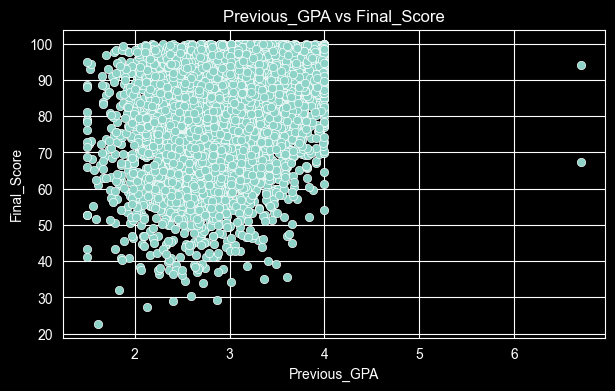

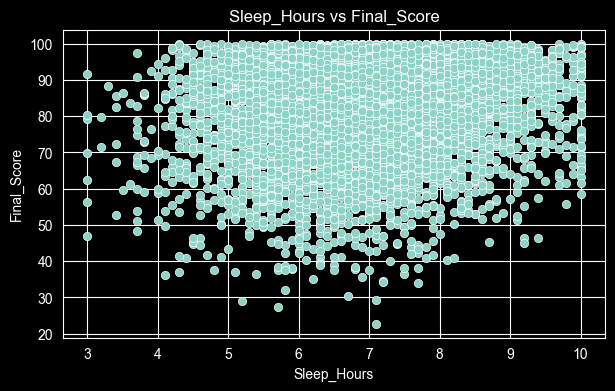

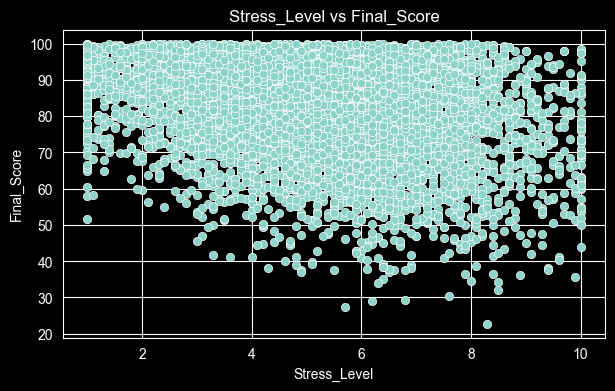

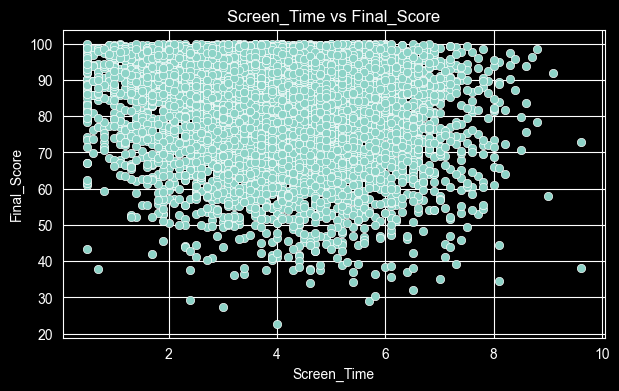

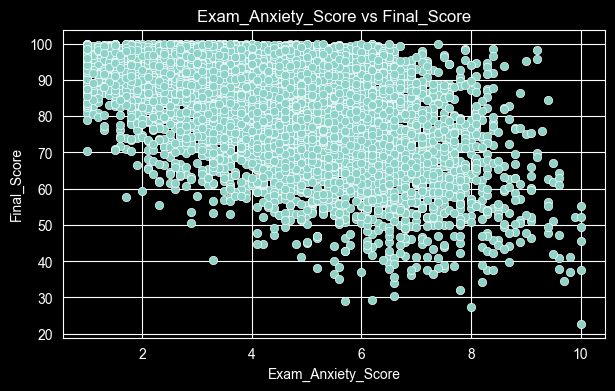

In [12]:
important_features = [
    "Hours_Studied",
    "Attendance",
    "Previous_GPA",
    "Sleep_Hours",
    "Stress_Level",
    "Screen_Time",
    "Exam_Anxiety_Score"
]

for col in important_features:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=df[col], y=df["Final_Score"])
    plt.title(f"{col} vs Final_Score")
    plt.show()

In [13]:
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
cat_cols

['Student_ID',
 'Gender',
 'Part_Time_Job',
 'Study_Method',
 'Diet_Quality',
 'Internet_Quality',
 'Extracurricular',
 'Family_Income_Level']

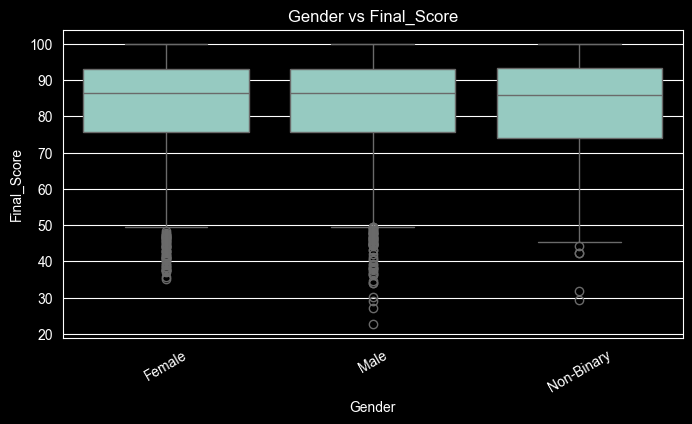

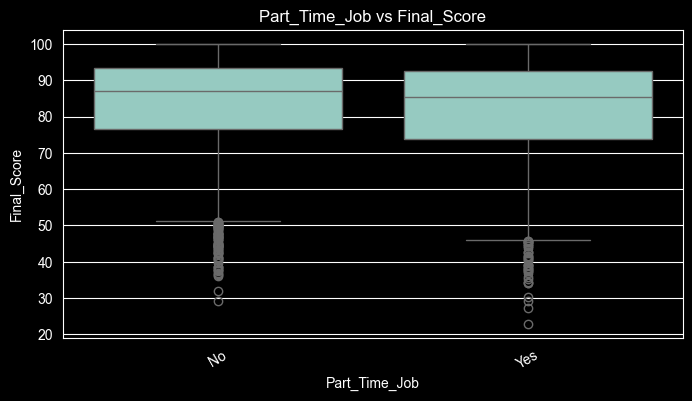

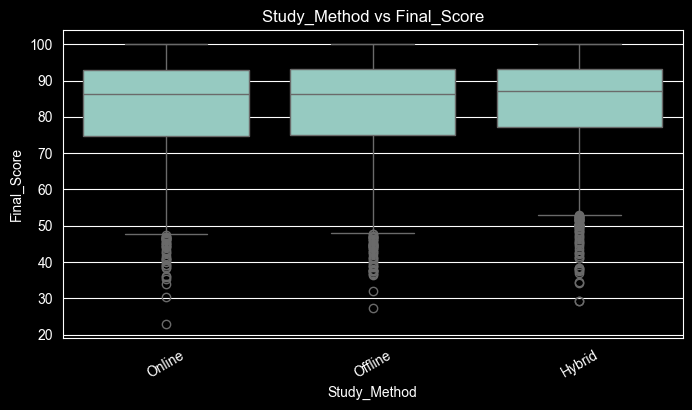

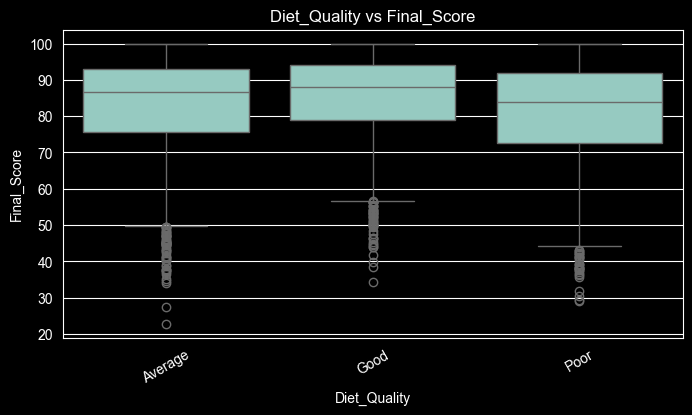

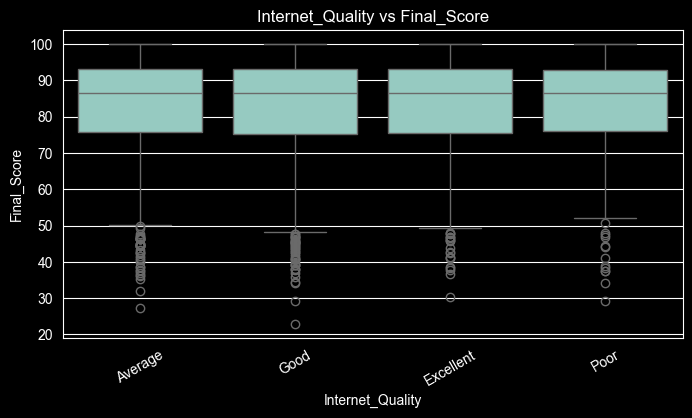

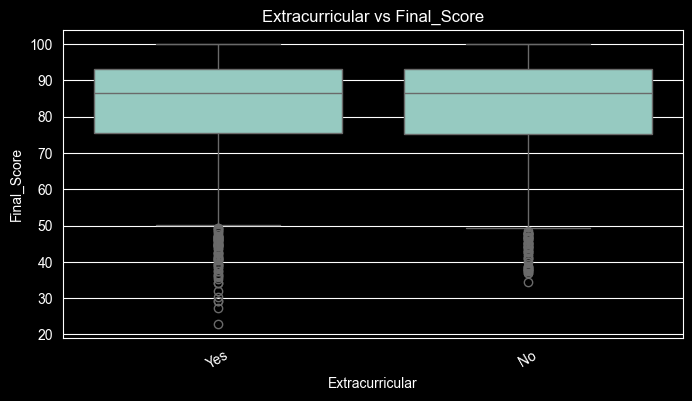

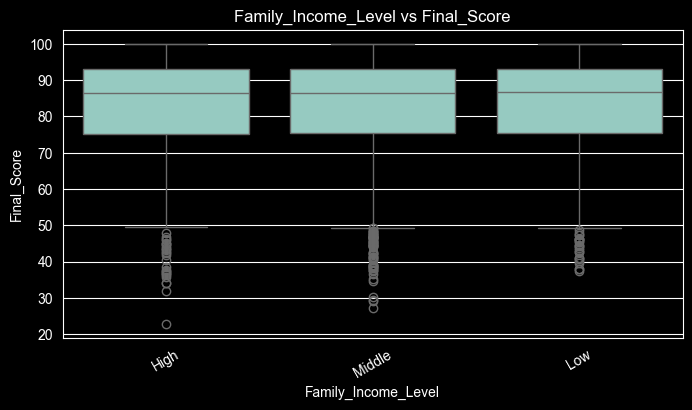

In [14]:
for col in cat_cols:
    if col != "Student_ID":
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col], y=df["Final_Score"])
        plt.title(f"{col} vs Final_Score")
        plt.xticks(rotation=30)
        plt.show()

### Interpretare EDA

În urma analizei se observă că variabilele cele mai relevante pentru predicția scorului final par a fi **Hours_Studied**, **Exam_Anxiety_Score** și **Tutoring_Sessions_Per_Week**.

Scatterplot-ul dintre `Hours_Studied` și `Final_Score` arată o relație pozitivă clară: studenții care petrec mai mult timp studiind tind să obțină rezultate mai bune. Acest lucru sugerează că timpul dedicat învățării influențează puternic performanța finală.

În cazul variabilei `Exam_Anxiety_Score`, se observă o relație negativă. Valorile mari ale anxietății sunt asociate cu scoruri finale mai mici, ceea ce indică faptul că stresul emoțional poate afecta rezultatele academice.

Pentru `Tutoring_Sessions_Per_Week`, corelația este pozitivă, ceea ce arată că studenții care participă mai frecvent la sesiuni suplimentare de pregătire tind să aibă performanțe mai ridicate.

Matricea de corelație confirmă faptul că `Hours_Studied` are cea mai mare corelație pozitivă cu variabila țintă, iar `Exam_Anxiety_Score` una dintre cele mai mari corelații negative.

În concluzie, scorul final pare influențat în principal de nivelul de implicare în studiu, suportul educațional suplimentar și factorii emoționali precum anxietatea la examene.

### Preprocesarea datelor
În această secțiune selectăm variabilele, eliminăm coloanele care nu trebuie folosite și pregătim datele pentru antrenare.

In [15]:
df = df.drop(columns=["Student_ID"])

In [16]:
X = df.drop(columns=["Final_Score"])
y = df["Final_Score"]

In [17]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()

numeric_features, categorical_features

(['Age',
  'Hours_Studied',
  'Attendance',
  'Sleep_Hours',
  'Stress_Level',
  'Screen_Time',
  'Previous_GPA',
  'Tutoring_Sessions_Per_Week',
  'Exam_Anxiety_Score'],
 ['Gender',
  'Part_Time_Job',
  'Study_Method',
  'Diet_Quality',
  'Internet_Quality',
  'Extracurricular',
  'Family_Income_Level'])

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
X_train.shape, X_test.shape

((6000, 16), (2000, 16))

## Observații de preprocesare

Coloana `Student_ID` a fost eliminată deoarece reprezintă doar un identificator unic.

Variabilele numerice au fost standardizate folosind `StandardScaler`, iar variabilele categorice au fost transformate prin `OneHotEncoder`.

Datele au fost împărțite în 75% pentru antrenare și 25% pentru testare, conform cerinței proiectului.

## 3. Antrenare și compararea modelelor de bază
În această etapă antrenăm toți algoritmii de clasificare.

In [20]:
from sklearn.svm import SVR

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbor Regressor": KNeighborsRegressor(),
    "Gaussian Process Regressor": GaussianProcessRegressor(),
    "XGBoost Regressor": XGBRegressor(random_state=42, n_estimators=100, max_depth=4),
    "CatBoost Regressor": CatBoostRegressor(verbose=0, random_state=42, iterations=100),
    "Explainable Boosting Regressor": ExplainableBoostingRegressor(random_state=42)
}

In [21]:
def evaluate_regression_model(name, model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results = {
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    return results, pipeline

In [22]:
regression_results = []
trained_regression_models = {}

In [23]:
res, fitted_model = evaluate_regression_model("Linear Regression", models["Linear Regression"], X_train, X_test, y_train, y_test)

regression_results.append(res)
trained_regression_models["Linear Regression"] = fitted_model

In [24]:
res, fitted_model = evaluate_regression_model("Decision Tree Regressor", models["Decision Tree Regressor"], X_train, X_test, y_train, y_test)

regression_results.append(res)
trained_regression_models["Decision Tree Regressor"] = fitted_model

In [25]:
res, fitted_model = evaluate_regression_model("Random Forest Regressor", models["Random Forest Regressor"], X_train, X_test, y_train, y_test)

regression_results.append(res)
trained_regression_models["Random Forest Regressor"] = fitted_model

In [26]:
res, fitted_model = evaluate_regression_model("K-Nearest Neighbor Regressor", models["K-Nearest Neighbor Regressor"], X_train, X_test, y_train, y_test)

regression_results.append(res)
trained_regression_models["K-Nearest Neighbor Regressor"] = fitted_model

In [27]:
res, fitted_model = evaluate_regression_model(
    "Gaussian Process Regressor",
    models["Gaussian Process Regressor"],
    X_train, X_test, y_train, y_test
)

regression_results.append(res)
trained_regression_models["Gaussian Process Regressor"] = fitted_model

In [28]:
res, fitted_model = evaluate_regression_model(
    "XGBoost Regressor",
    models["XGBoost Regressor"],
    X_train, X_test, y_train, y_test
)

regression_results.append(res)
trained_regression_models["XGBoost Regressor"] = fitted_model

In [29]:
res, fitted_model = evaluate_regression_model(
    "CatBoost Regressor",
    models["CatBoost Regressor"],
    X_train, X_test, y_train, y_test
)

regression_results.append(res)
trained_regression_models["CatBoost Regressor"] = fitted_model

In [30]:
res, fitted_model = evaluate_regression_model(
    "Explainable Boosting Regressor",
    models["Explainable Boosting Regressor"],
    X_train, X_test, y_train, y_test
)

regression_results.append(res)
trained_regression_models["Explainable Boosting Regressor"] = fitted_model

In [31]:
res, fitted_model = evaluate_regression_model(
    "Support Vector Regressor",
    models["Support Vector Regressor"],
    X_train, X_test, y_train, y_test
)

regression_results.append(res)
trained_regression_models["Support Vector Regressor"] = fitted_model

In [32]:
regression_results_df = pd.DataFrame(regression_results).sort_values(by="R2", ascending=False)
regression_results_df

,Model,MSE,MAE,RMSE,R2
7,Explainable Boosting Regressor,41.309303,5.030018,6.427231,0.747950
8,Support Vector Regressor,43.635238,5.152936,6.605697,0.733758
6,CatBoost Regressor,44.199938,5.225677,6.648303,0.730312
5,XGBoost Regressor,46.960479,5.355841,6.852772,0.713469
2,Random Forest Regressor,49.077679,5.448216,7.005546,0.700551
0,Linear Regression,50.747531,5.601141,7.123730,0.690362
3,K-Nearest Neighbor Regressor,60.590485,6.078786,7.783989,0.630305
1,Decision Tree Regressor,111.393661,8.094485,10.554320,0.320327
4,Gaussian Process Regressor,2407.954166,43.814164,49.070910,-13.692232


In [33]:
top5_rmodels = regression_results_df["Model"].head(5).tolist()
top5_rmodels

['Explainable Boosting Regressor',
 'Support Vector Regressor',
 'CatBoost Regressor',
 'XGBoost Regressor',
 'Random Forest Regressor']

### Concluzii după modelele de bază

În urma comparării celor 9 algoritmi de regresie, cele mai bune rezultate au fost obținute de modelele mai avansate, bazate pe combinații de mai mulți arbori de decizie sau metode iterative de îmbunătățire a predicțiilor.

Cel mai performant model a fost **Explainable Boosting Regressor**, cu un scor **R² de 0.7479** și **RMSE de 6.43**, urmat de **Support Vector Regressor** și **CatBoost Regressor**.

Modelele simple, precum **Linear Regression**, au avut rezultate decente, însă mai slabe decât modelele complexe. **Decision Tree Regressor** și **Gaussian Process Regressor** au avut cele mai slabe performanțe.

Pe baza scorului **R²**, au fost selectate primele 5 modele pentru etapa de optimizare a hiperparametrilor:

- Explainable Boosting Regressor
- Support Vector Regressor
- CatBoost Regressor
- XGBoost Regressor
- Random Forest Regressor

## 4. Ajustarea hiperparametrilor
În această etapă optimizăm primele 5 modele folosind GridSearchCV.

In [34]:
param_grids = {
    "Support Vector Regressor": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf", "linear"]
    },
    "XGBoost Regressor": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1]
    },
    "CatBoost Regressor": {
        "model__iterations": [100, 200],
        "model__depth": [4, 6],
        "model__learning_rate": [0.05, 0.1]
    },
    "Explainable Boosting Regressor": {
        "model__max_rounds": [50, 100]
    },
    "Random Forest Regressor": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [5, 10, None]
    }
}

In [35]:
tuned_regression_results = []
best_regression_estimators = {}

In [36]:
def tune_regression_model(model_name):
    model = models[model_name]

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    param_grid = param_grids.get(model_name, {})

    if param_grid == {}:
        pipeline.fit(X_train, y_train)
        best_model = pipeline
        best_params = {}
    else:
        grid = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            cv=3,
            scoring="r2",
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        best_params = grid.best_params_

    y_pred = best_model.predict(X_test)

    result = {
        "Model": model_name,
        "Best Params": best_params,
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

    return result, best_model

In [37]:
model_name = top5_rmodels[0]
res, best_model = tune_regression_model(model_name)

tuned_regression_results.append(res)
best_regression_estimators[model_name] = best_model

In [38]:
model_name = top5_rmodels[1]
res, best_model = tune_regression_model(model_name)

tuned_regression_results.append(res)
best_regression_estimators[model_name] = best_model

In [39]:
model_name = top5_rmodels[2]
res, best_model = tune_regression_model(model_name)

tuned_regression_results.append(res)
best_regression_estimators[model_name] = best_model

In [40]:
model_name = top5_rmodels[3]
res, best_model = tune_regression_model(model_name)

tuned_regression_results.append(res)
best_regression_estimators[model_name] = best_model

In [41]:
model_name = top5_rmodels[4]
res, best_model = tune_regression_model(model_name)

tuned_regression_results.append(res)
best_regression_estimators[model_name] = best_model

In [42]:
tuned_regression_df = pd.DataFrame(tuned_regression_results).sort_values(by="R2", ascending=False)
tuned_regression_df

,Model,Best Params,MSE,MAE,RMSE,R2
2,CatBoost Regressor,"{'model__depth': 6, 'model__iterations': 200, ...",40.994605,5.021453,6.402703,0.749870
0,Explainable Boosting Regressor,{'model__max_rounds': 100},41.271739,5.034914,6.424308,0.748179
1,Support Vector Regressor,"{'model__C': 10, 'model__kernel': 'rbf'}",43.074878,5.142689,6.563145,0.737177
3,XGBoost Regressor,"{'model__learning_rate': 0.1, 'model__max_dept...",44.132654,5.179933,6.643241,0.730723
4,Random Forest Regressor,"{'model__max_depth': None, 'model__n_estimator...",49.077679,5.448216,7.005546,0.700551


In [43]:
final_regression_model_name = tuned_regression_df.iloc[0]["Model"]
final_regression_model = best_regression_estimators[final_regression_model_name]

final_regression_model_name

'CatBoost Regressor'

### Concluzii după ajustarea hiperparametrilor

După optimizarea hiperparametrilor, performanța principalelor modele de regresie s-a îmbunătățit ușor, ceea ce confirmă importanța alegerii corecte a parametrilor de antrenare.

Cel mai bun rezultat a fost obținut de **CatBoost Regressor**, cu:
- **R2 = 0.74**
- **RMSE = 6.40**
- **MAE = 5.02**

Acesta a depășit ușor modelul **Explainable Boosting Regressor**, care înainte ocupa prima poziție.

Modelul **Support Vector Regressor** a rămas competitiv, iar **XGBoost Regressor** și **Random Forest Regressor** au avut rezultate bune, însă inferioare primelor modele.

Diferențele dintre primele două modele sunt mici, ceea ce arată că ambele pot fi considerate opțiuni foarte bune.

Nu apar semne evidente de overfitting în această etapă, deoarece performanțele pe setul de testare au rămas stabile după tuning.

În concluzie, după ajustarea hiperparametrilor, **CatBoost Regressor** a devenit modelul final selectat pentru această problemă.

## 5. Curbele de învățare
Afișăm learning curves pentru cele mai bune 5 modele și discutăm overfitting/underfitting.

In [44]:
def plot_regression_learning_curve(model, title, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=3,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, marker="o", label="Train R2")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation R2")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("R2 Score")
    plt.legend()
    plt.grid(True)
    plt.show()

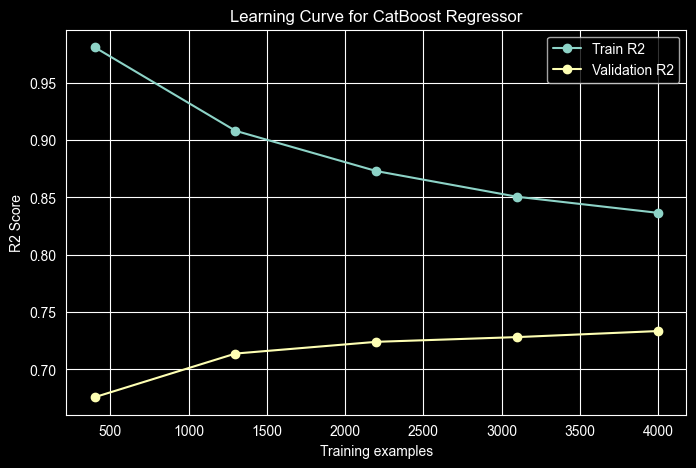

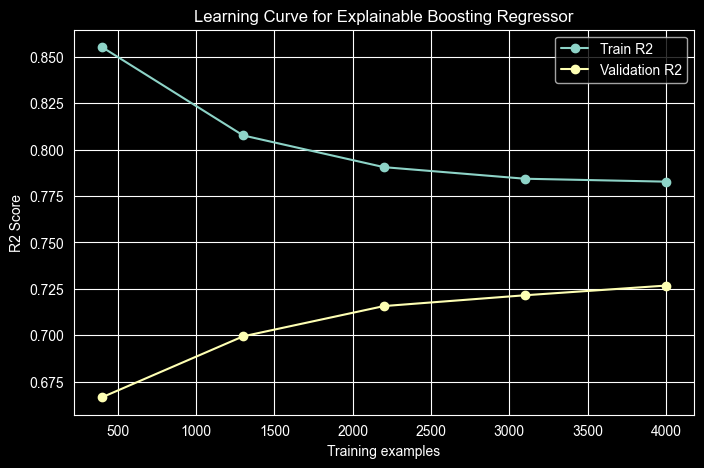

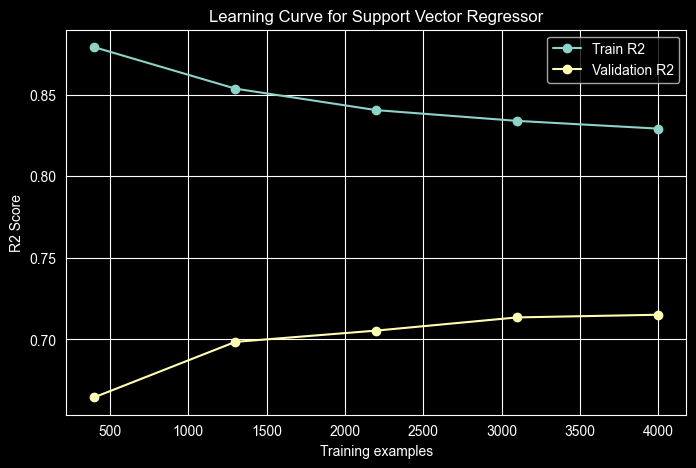

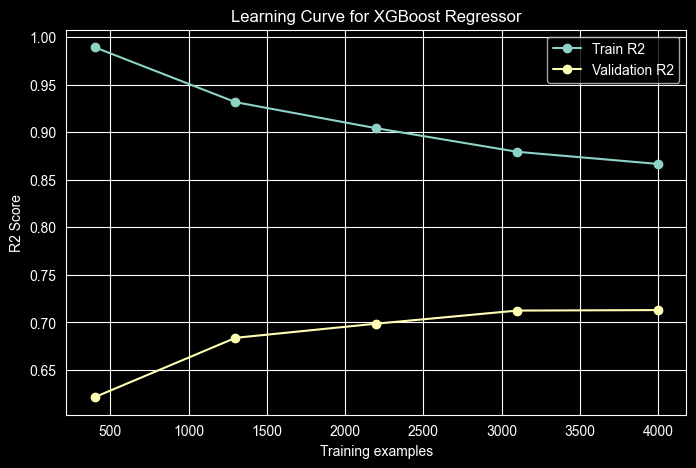

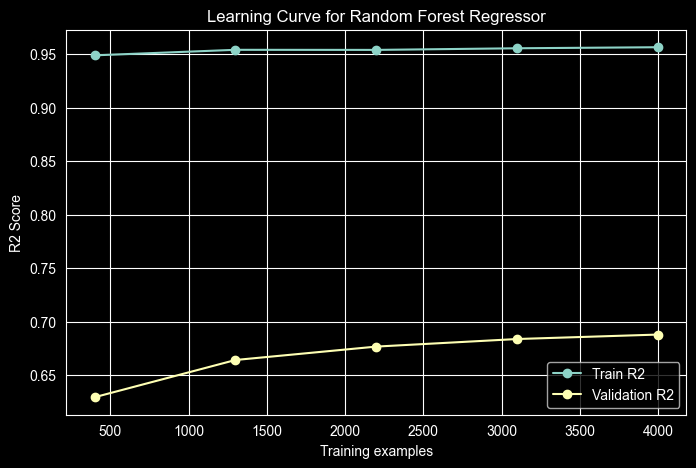

In [45]:
for model_name in tuned_regression_df["Model"].head(5):
    plot_regression_learning_curve(
        best_regression_estimators[model_name],
        f"Learning Curve for {model_name}",
        X_train,
        y_train
    )

## Interpretarea curbelor de învățare

Curbele de învățare au fost analizate pentru primele modele după etapa de tuning, folosind scorul **R²** pe setul de antrenare și validare.

### Observații generale

- Pentru toate modelele, scorul de antrenare este mai mare decât scorul de validare, ceea ce este normal.
- Pe măsură ce crește numărul de exemple, scorul de antrenare scade ușor, iar cel de validare crește.
- Acest comportament arată că modelele generalizează mai bine când primesc mai multe date.

### CatBoost Regressor

- Are cel mai bun scor de validare.
- Curbele se apropie treptat pe măsură ce cresc datele de antrenare.
- Există un ușor overfitting la volume mici de date, dar acesta se reduce ulterior.
- Modelul are performanță foarte bună și stabilă.

### Explainable Boosting Regressor

- Curbele sunt apropiate și stabile.
- Diferența dintre train și validation este redusă.
- Modelul generalizează bine și prezintă risc mic de overfitting.
- Este una dintre cele mai echilibrate variante.

### Support Vector Regressor

- Curbe stabile și constante.
- Gap moderat între train și validation.
- Model robust, dar cu performanță puțin mai mică decât primele două.

### XGBoost Regressor

- Scor foarte mare pe train și mai mic pe validation.
- Diferența mai mare dintre curbe sugerează overfitting moderat.
- Cu mai multe date, validarea crește, dar gap-ul rămâne.

### Concluzie

Dintre toate modelele analizate, **CatBoost Regressor** oferă cel mai bun compromis între performanță și capacitate de generalizare, motiv pentru care rămâne modelul final selectat. **Explainable Boosting Regressor** este o alternativă foarte bună datorită stabilității și interpretabilității sale.

## 6. Explicabilitatea și analiza SHAP

În această secțiune interpretăm primele 3 modele perfecționate folosind SHAP:
- CatBoost Regressor
- Explainable Boosting Regressor
- Support Vector Regressor

In [46]:
import shap

top3_regression_models = [
    "CatBoost Regressor",
    "Explainable Boosting Regressor",
    "Support Vector Regressor"
]

sample_X = X_test.sample(min(100, len(X_test)), random_state=42)
background_X = X_train.sample(min(100, len(X_train)), random_state=42)

top3_regression_models

['CatBoost Regressor',
 'Explainable Boosting Regressor',
 'Support Vector Regressor']

In [47]:
def get_transformed_data(model_pipe, X_data):
    X_transformed = model_pipe.named_steps["preprocessor"].transform(X_data)

    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()

    preprocessor_fitted = model_pipe.named_steps["preprocessor"]

    num_names = preprocessor_fitted.named_transformers_["num"].get_feature_names_out(numeric_features)
    cat_names = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)

    feature_names = np.concatenate([num_names, cat_names])

    return pd.DataFrame(X_transformed, columns=feature_names)

## 6.1. SHAP pentru CatBoost Regressor

In [48]:
cat_pipe = best_regression_estimators["CatBoost Regressor"]

cat_model = cat_pipe.named_steps["model"]

cat_background = get_transformed_data(cat_pipe, background_X)
cat_sample = get_transformed_data(cat_pipe, sample_X)

In [49]:
cat_explainer = shap.Explainer(cat_model.predict, cat_background)
cat_shap_values = cat_explainer(cat_sample)

PermutationExplainer explainer: 101it [00:16,  6.23it/s]                        


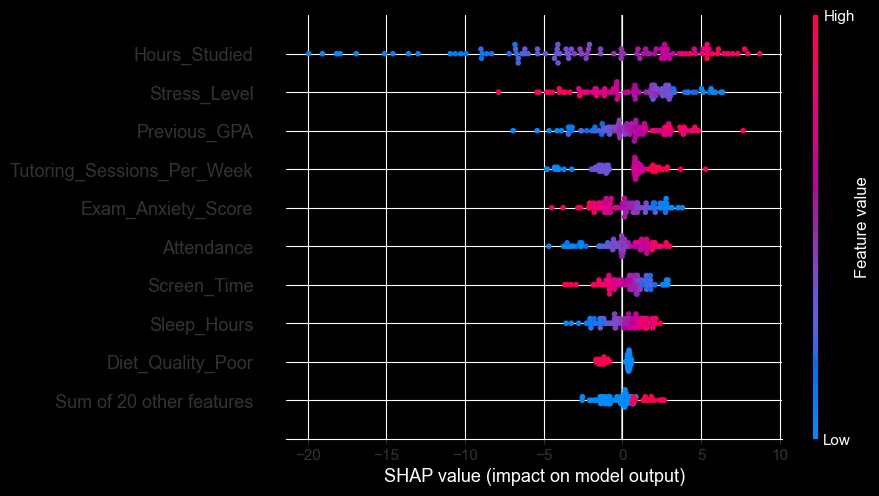

In [50]:
shap.plots.beeswarm(cat_shap_values)

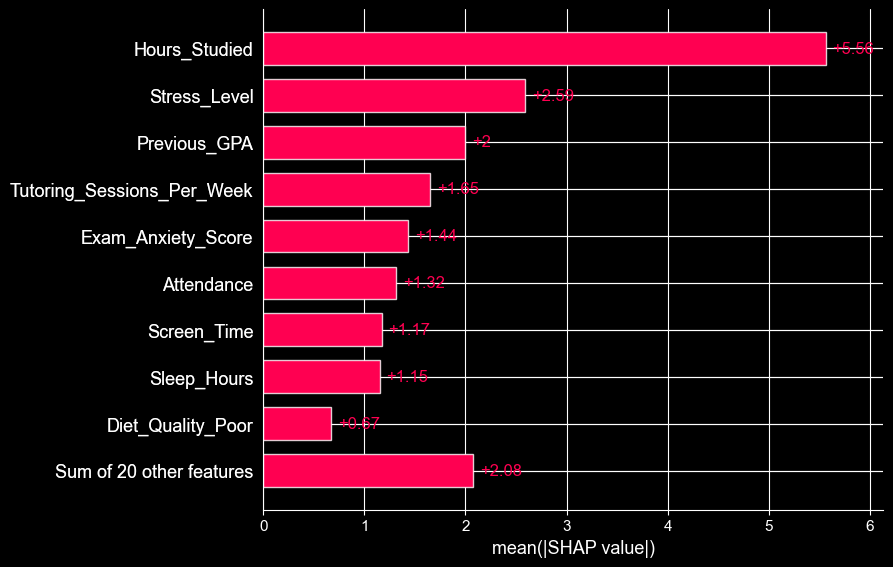

In [51]:
shap.plots.bar(cat_shap_values)

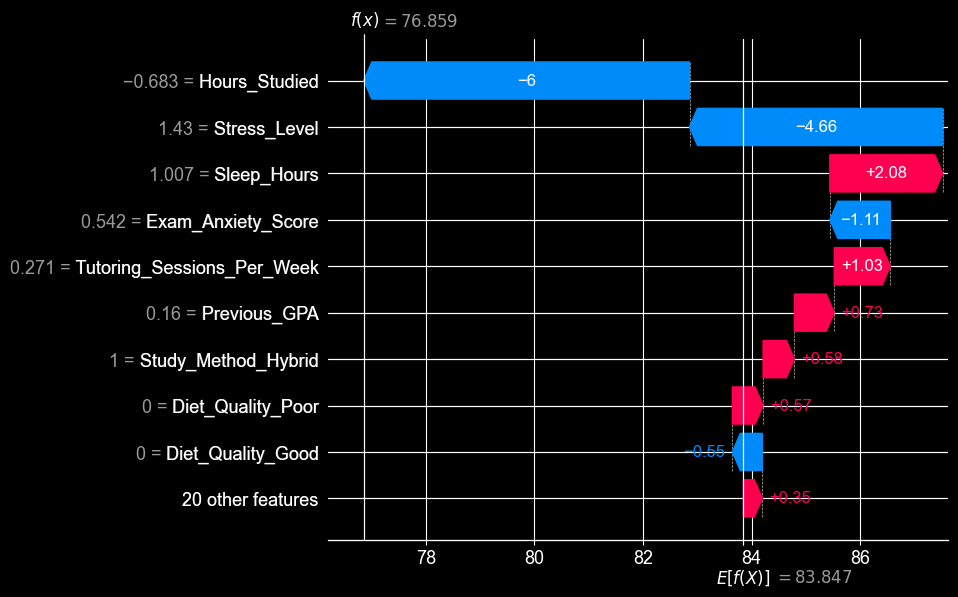

In [52]:
shap.plots.waterfall(cat_shap_values[0])

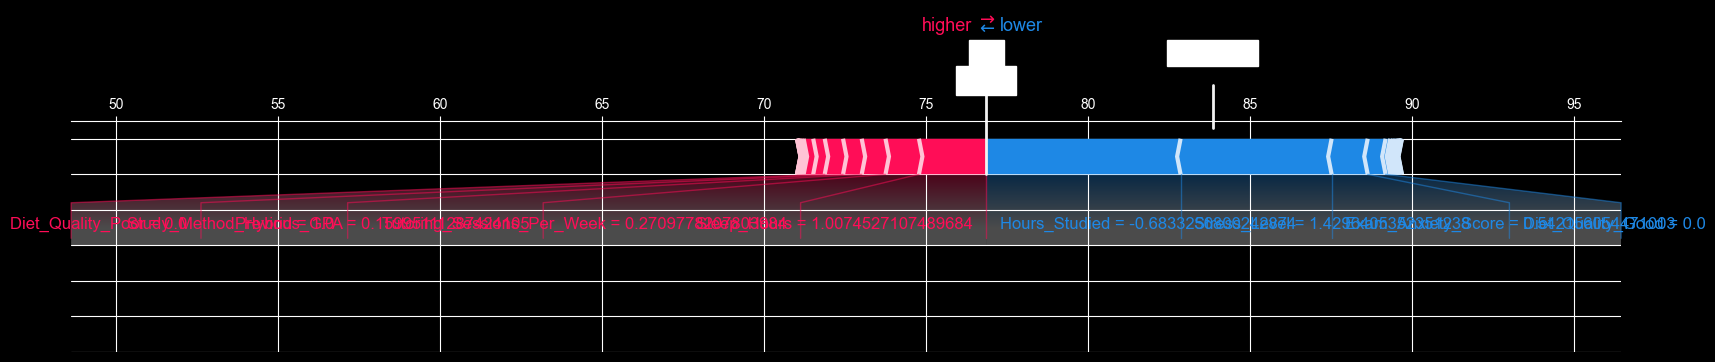

In [53]:
shap.force_plot(
    cat_shap_values.base_values[0],
    cat_shap_values.values[0],
    cat_sample.iloc[0],
    matplotlib=True
)
plt.show()

In [54]:
cat_importance = pd.DataFrame({
    "Feature": cat_sample.columns,
    "MeanAbsSHAP": np.abs(cat_shap_values.values).mean(axis=0)
}).sort_values(by="MeanAbsSHAP", ascending=False)

cat_importance.head(10)

,Feature,MeanAbsSHAP
1,Hours_Studied,5.560604
4,Stress_Level,2.592149
6,Previous_GPA,1.995381
7,Tutoring_Sessions_Per_Week,1.652848
8,Exam_Anxiety_Score,1.435142
2,Attendance,1.316725
5,Screen_Time,1.171831
3,Sleep_Hours,1.152575
19,Diet_Quality_Poor,0.673040
18,Diet_Quality_Good,0.661746


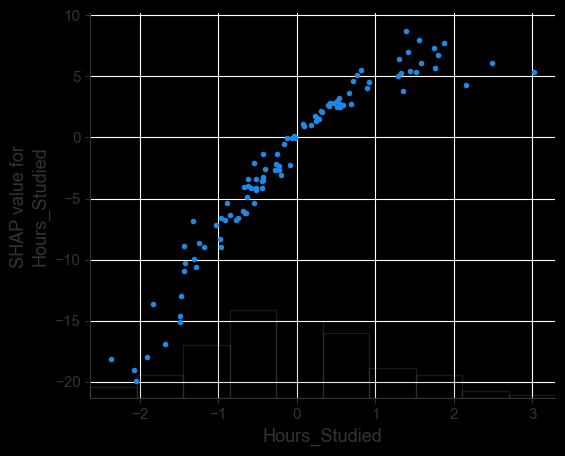

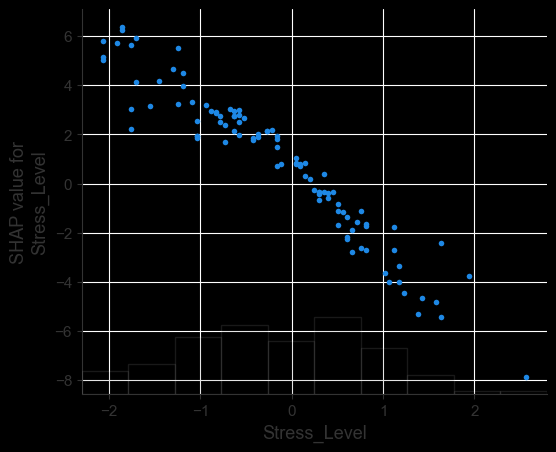

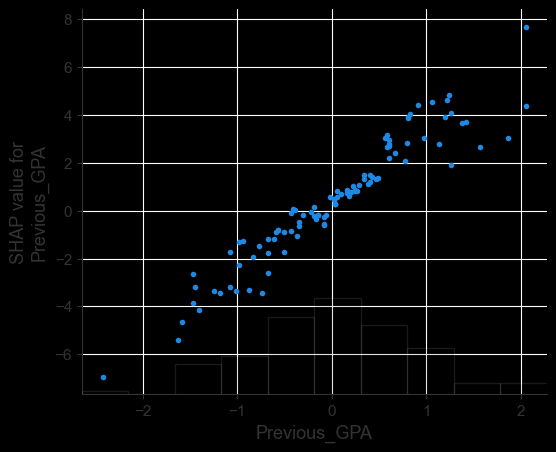

In [55]:
top3_features_cat = cat_importance["Feature"].head(3).tolist()

for feat in top3_features_cat:
    shap.plots.scatter(cat_shap_values[:, feat])

### Interpretare SHAP pentru CatBoost Regressor

Analiza SHAP arată că cele mai importante variabile pentru predicția scorului final sunt **Hours_Studied**, **Stress_Level** și **Previous_GPA**.

- **Hours_Studied** are impact pozitiv: mai multe ore de studiu cresc scorul estimat.
- **Stress_Level** are impact negativ: stresul ridicat scade scorul prezis.
- **Previous_GPA** influențează pozitiv: elevii cu rezultate anterioare bune tind să obțină scoruri mai mari.

Alte variabile importante sunt **Tutoring_Sessions_Per_Week**, **Exam_Anxiety_Score** și **Attendance**.

### Interpretare locală

Pentru observația analizată, modelul a prezis **76.86** puncte, sub media generală (**83.85**).

Scorul a fost redus în special de:

- puține ore de studiu
- nivel ridicat de stres

Scorul a fost crescut de:

- GPA anterior bun
- ore suficiente de somn
- sesiuni de tutoring

### Concluzie

Modelul confirmă că implicarea în studiu și performanța anterioară cresc rezultatul final, iar stresul și anxietatea îl reduc.

## 6.2. SHAP pentru Explainable Boosting Regressor

In [56]:
ebm_pipe = best_regression_estimators["Explainable Boosting Regressor"]

ebm_model = ebm_pipe.named_steps["model"]

ebm_background = get_transformed_data(ebm_pipe, background_X)
ebm_sample = get_transformed_data(ebm_pipe, sample_X)

In [57]:
ebm_sample = pd.DataFrame(
    ebm_sample.values,
    columns=ebm_model.feature_names_in_
)

ebm_background = pd.DataFrame(
    ebm_background.values,
    columns=ebm_model.feature_names_in_
)

In [58]:
ebm_explainer = shap.Explainer(ebm_model.predict, ebm_background)
ebm_shap_values = ebm_explainer(ebm_sample)

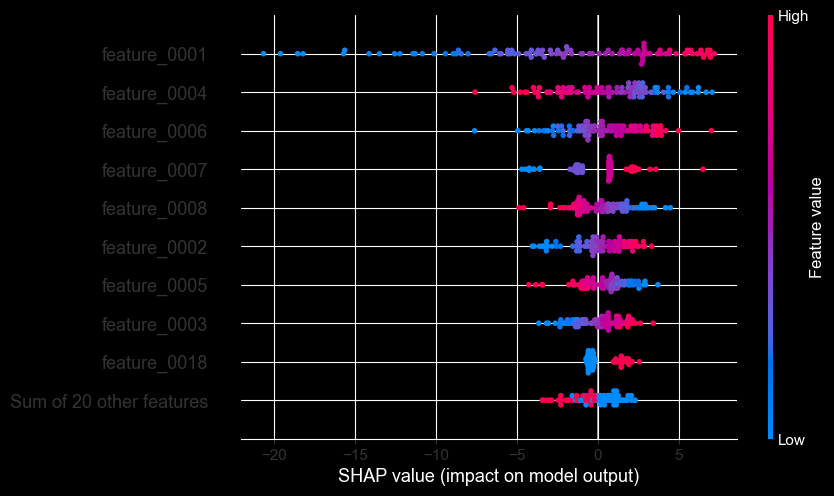

In [59]:
shap.plots.beeswarm(ebm_shap_values)

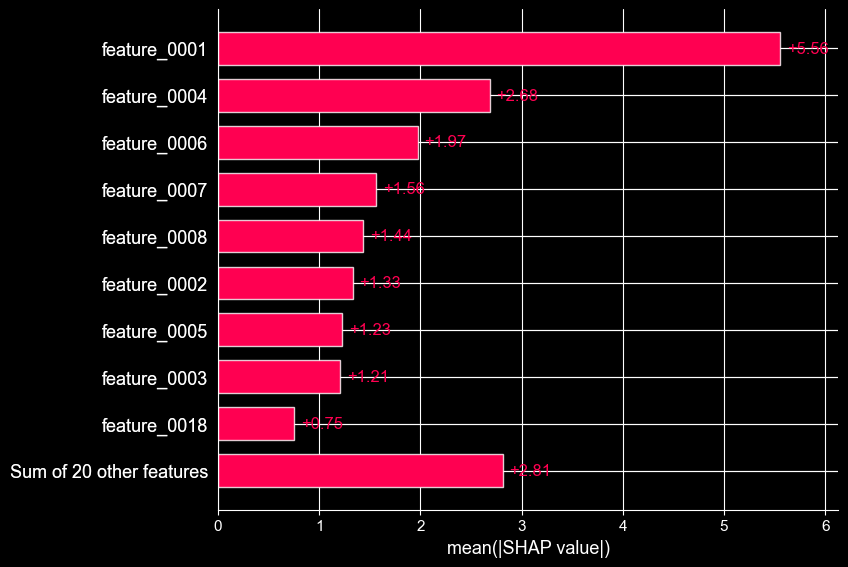

In [60]:
shap.plots.bar(ebm_shap_values)

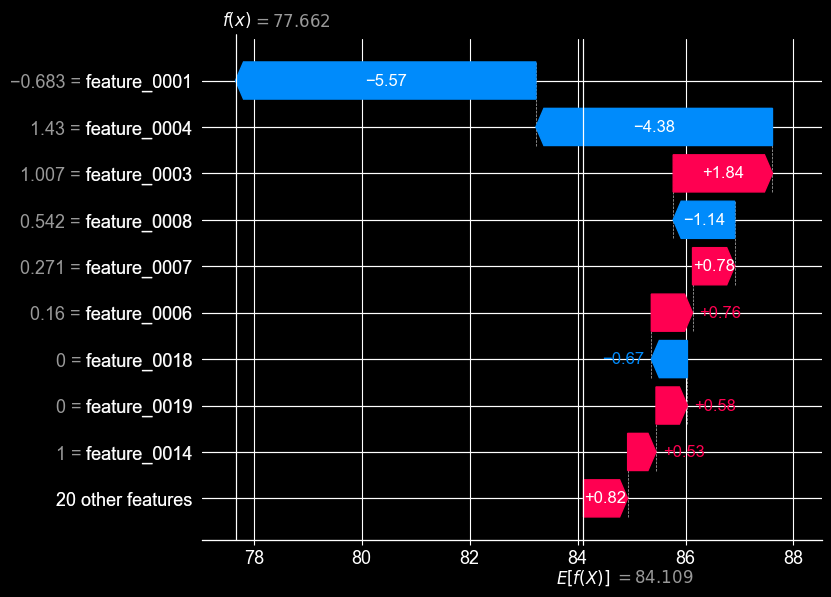

In [61]:
shap.plots.waterfall(ebm_shap_values[0])

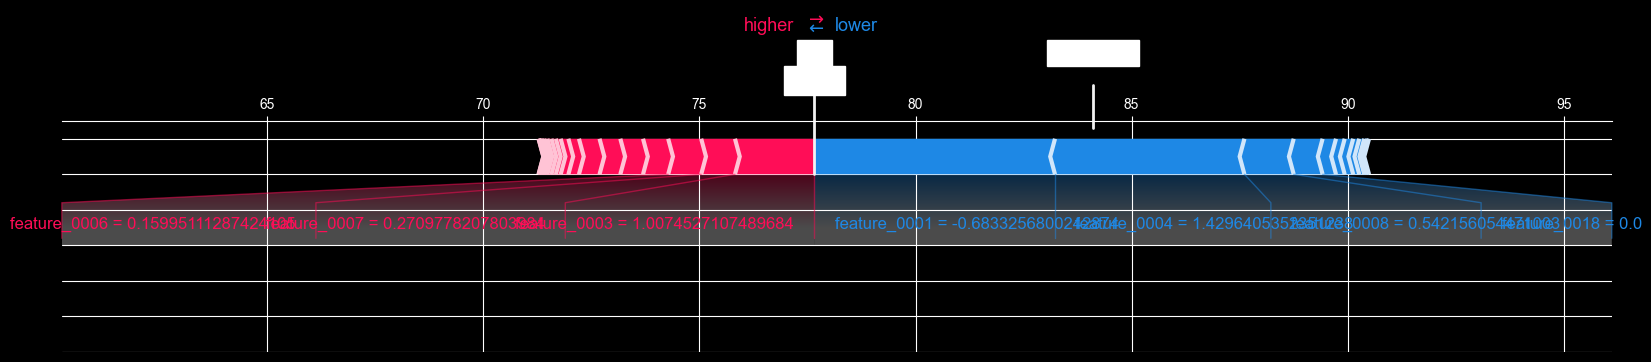

In [62]:
shap.force_plot(
    ebm_shap_values.base_values[0],
    ebm_shap_values.values[0],
    ebm_sample.iloc[0],
    matplotlib=True
)
plt.show()

In [63]:
ebm_importance = pd.DataFrame({
    "Feature": ebm_sample.columns,
    "MeanAbsSHAP": np.abs(ebm_shap_values.values).mean(axis=0)
}).sort_values(by="MeanAbsSHAP", ascending=False)

ebm_importance.head(10)

,Feature,MeanAbsSHAP
1,feature_0001,5.557691
4,feature_0004,2.683359
6,feature_0006,1.973621
7,feature_0007,1.561077
8,feature_0008,1.436301
2,feature_0002,1.330332
5,feature_0005,1.228933
3,feature_0003,1.205162
18,feature_0018,0.752303
19,feature_0019,0.722469


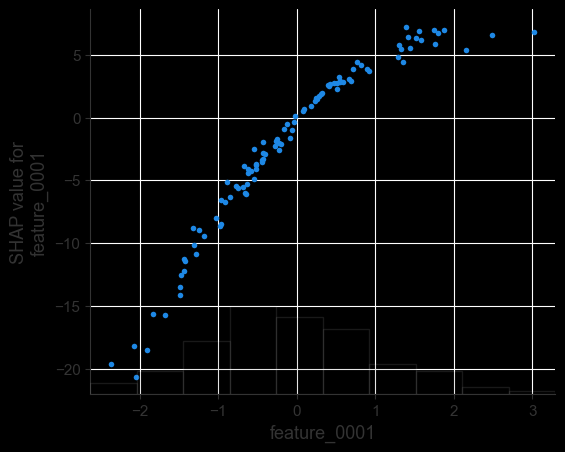

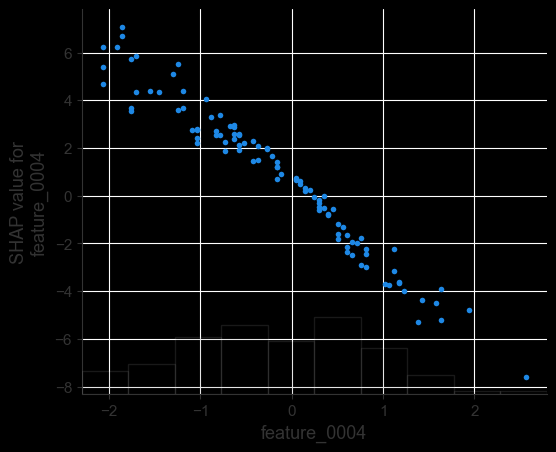

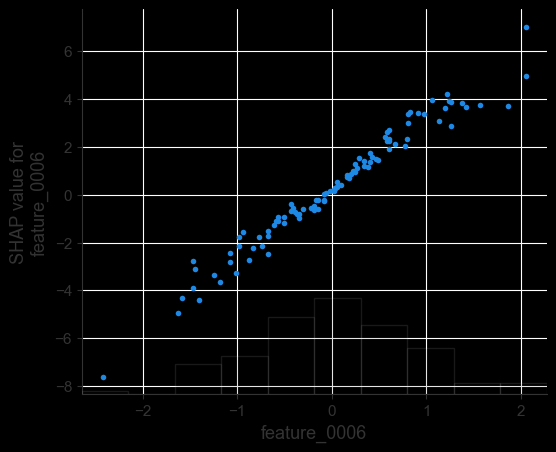

In [64]:
top3_features_ebm = ebm_importance["Feature"].head(3).tolist()

for feat in top3_features_ebm:
    shap.plots.scatter(ebm_shap_values[:, feat])

### Interpretarea SHAP – Explainable Boosting Regressor

Analiza SHAP confirmă faptul că modelul Explainable Boosting Regressor ia decizia de predicție în principal pe baza câtorva variabile importante, iar relațiile dintre acestea și scorul final sunt clare și interpretabile.

Conform graficului de importanță globală, cele mai relevante variabile sunt:

1. `feature_0001`
2. `feature_0004`
3. `feature_0006`

Acestea au cea mai mare contribuție medie asupra predicțiilor modelului.

Din graficele dependence plot se observă următoarele:

- Pentru `feature_0001`, valorile mai mari cresc scorul prezis, iar valorile mici îl reduc semnificativ. Relația este aproape liniară pozitivă.
- Pentru `feature_0004`, relația este inversă: valorile mari reduc predicția, iar valorile mici o cresc.
- Pentru `feature_0006`, valorile ridicate contribuie pozitiv la scorul final, în timp ce valorile scăzute au impact negativ.

Graficul waterfall pentru o observație individuală arată cum modelul pornește de la valoarea medie estimată și ajustează predicția în funcție de fiecare caracteristică. În exemplul analizat, anumite variabile au scăzut predicția, iar altele au crescut-o, rezultând valoarea finală estimată.

În concluzie, modelul EBM oferă nu doar performanță bună, ci și un nivel ridicat de interpretabilitate, permițând înțelegerea modului în care fiecare variabilă influențează scorul final.

## 6.3. SHAP pentru Support Vector Regressor

In [65]:
svr_pipe = best_regression_estimators["Support Vector Regressor"]

svr_model = svr_pipe.named_steps["model"]

svr_background = get_transformed_data(svr_pipe, background_X)
svr_sample = get_transformed_data(svr_pipe, sample_X)

In [66]:
svr_explainer = shap.KernelExplainer(svr_model.predict, svr_background)
svr_shap_values = svr_explainer.shap_values(svr_sample, nsamples=100)

  0%|          | 0/100 [00:00<?, ?it/s]

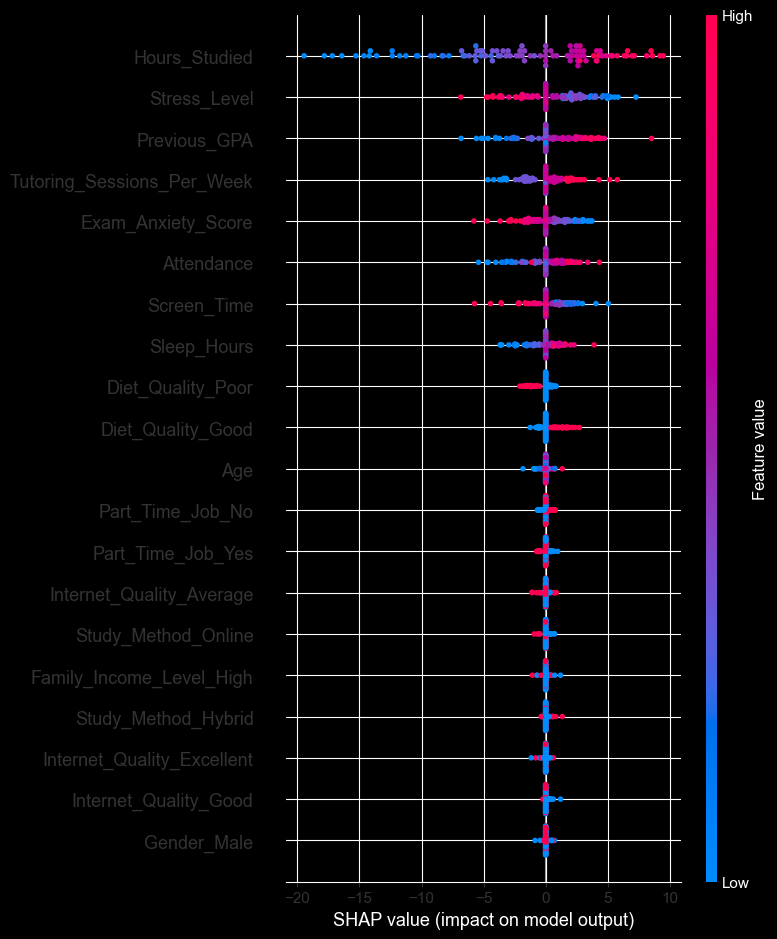

In [67]:
import warnings
warnings.filterwarnings("ignore")

shap.summary_plot(svr_shap_values, svr_sample)

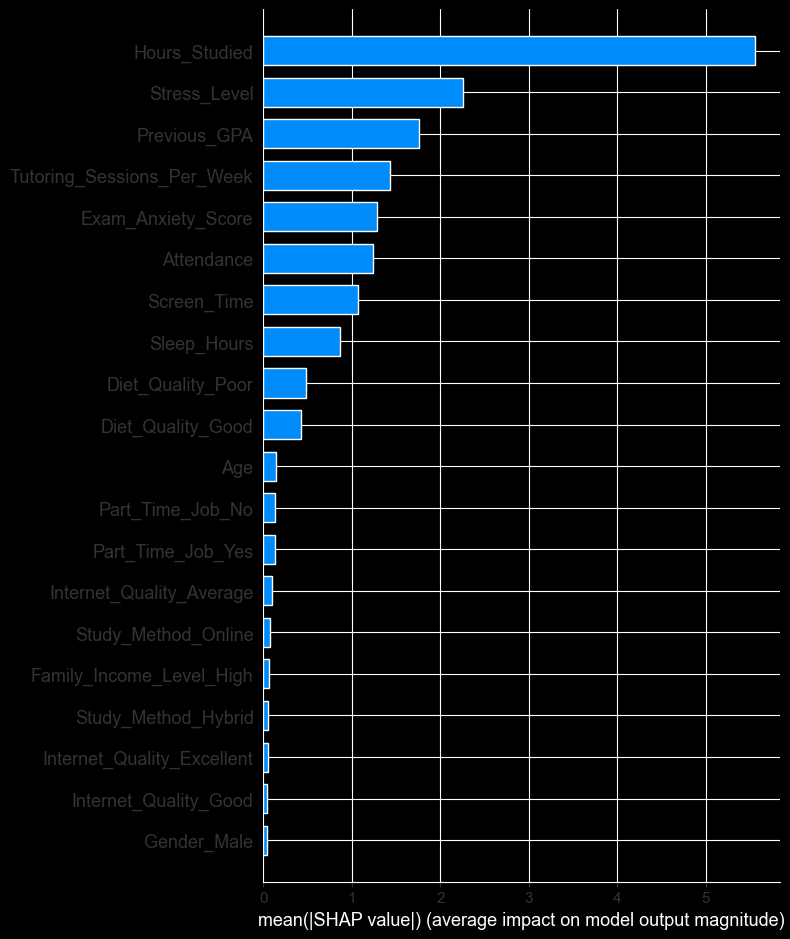

In [68]:
shap.summary_plot(svr_shap_values, svr_sample, plot_type="bar")

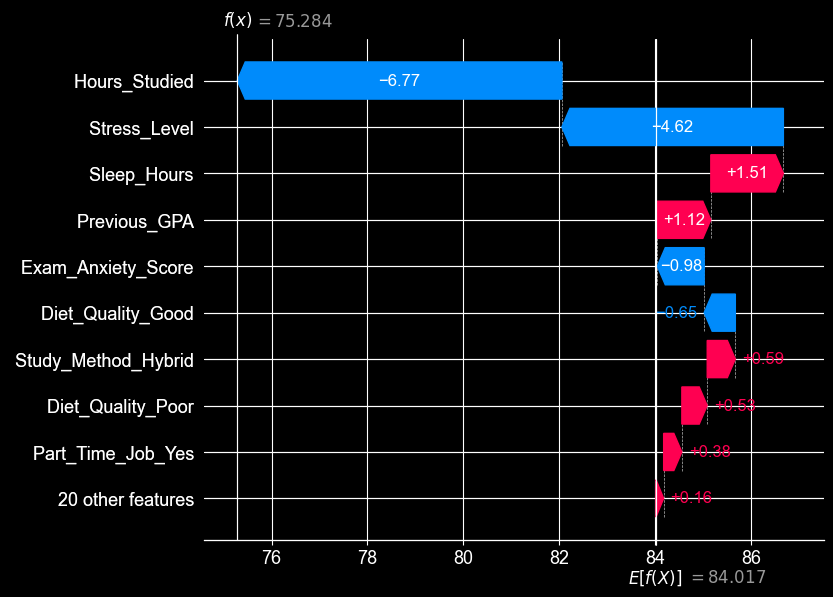

In [69]:
shap.plots._waterfall.waterfall_legacy(
    svr_explainer.expected_value,
    svr_shap_values[0],
    feature_names=svr_sample.columns,
    features=svr_sample.iloc[0]
)

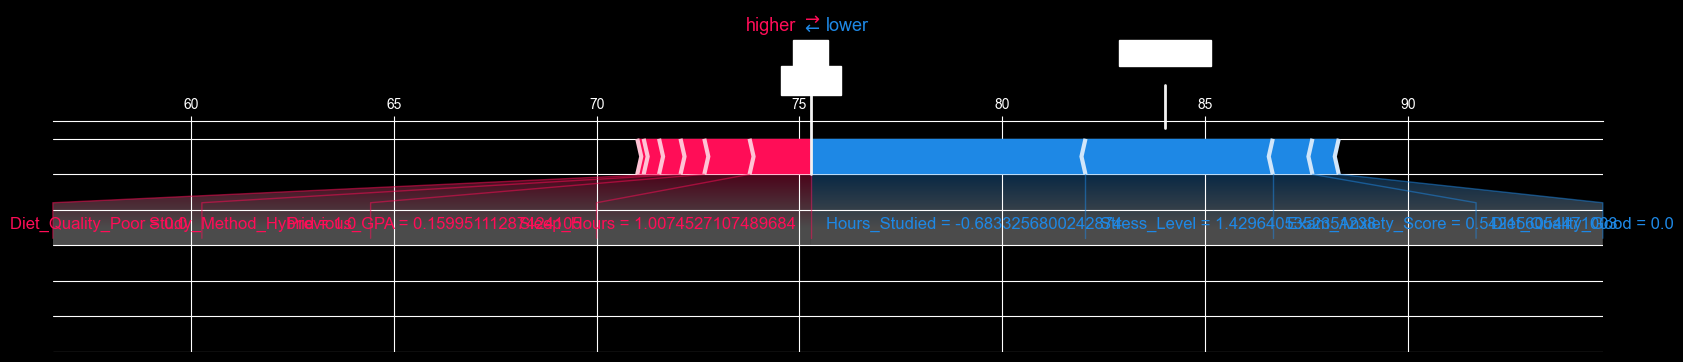

In [70]:
shap.force_plot(
    svr_explainer.expected_value,
    svr_shap_values[0],
    svr_sample.iloc[0],
    matplotlib=True
)
plt.show()

In [71]:
svr_importance = pd.DataFrame({
    "Feature": svr_sample.columns,
    "MeanAbsSHAP": np.abs(svr_shap_values).mean(axis=0)
}).sort_values(by="MeanAbsSHAP", ascending=False)

svr_importance.head(10)

,Feature,MeanAbsSHAP
1,Hours_Studied,5.558339
4,Stress_Level,2.255886
6,Previous_GPA,1.764772
7,Tutoring_Sessions_Per_Week,1.436662
8,Exam_Anxiety_Score,1.288898
2,Attendance,1.235096
5,Screen_Time,1.075147
3,Sleep_Hours,0.869435
19,Diet_Quality_Poor,0.488434
18,Diet_Quality_Good,0.428006


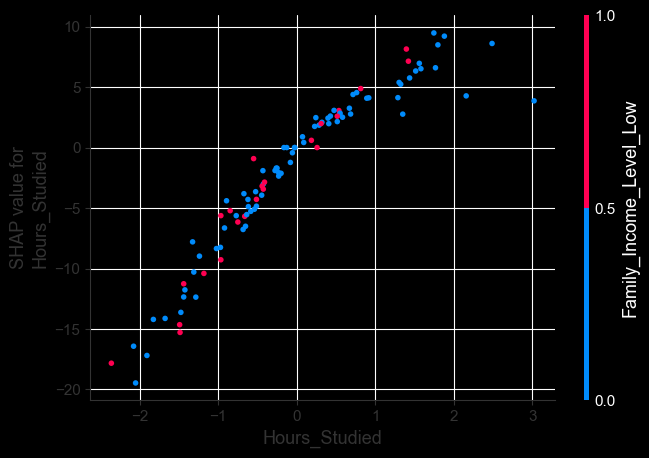

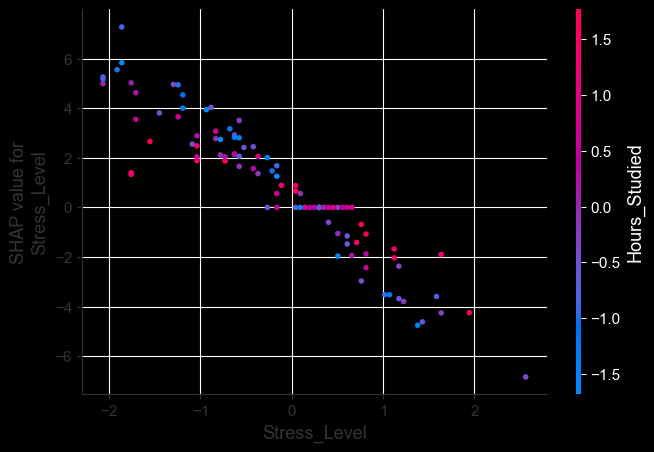

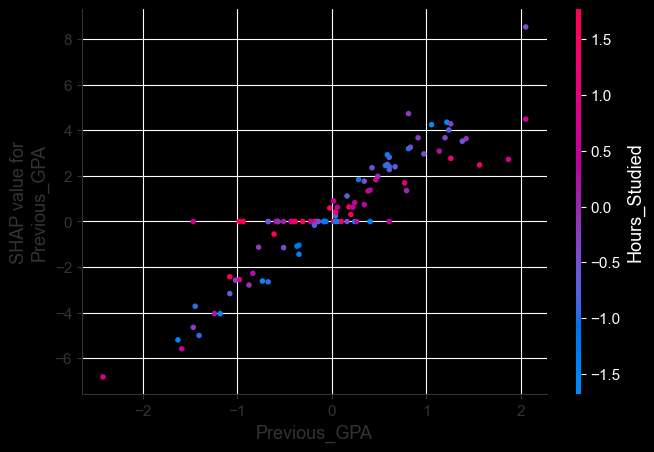

In [72]:
top3_features_svr = svr_importance["Feature"].head(3).tolist()

for feat in top3_features_svr:
    shap.dependence_plot(feat, svr_shap_values, svr_sample)

### Interpretare SHAP - Support Vector Regressor

Analiza SHAP arată faptul că modelul Support Vector Regressor realizează predicțiile pe baza mai multor variabile relevante, iar influența acestora asupra scorului final poate fi observată clar.

Conform graficului de importanță globală, cele mai relevante variabile sunt:
1. `Hours_Studied`
2. `Stress_Level`
3. `Previous_GPA`

Aceste variabile au cea mai mare contribuție medie asupra predicțiilor modelului.

Din graficele dependence plot se observă următoarele:
- Pentru `Hours_Studied`, valorile mai mari cresc scorul prezis, iar valorile mici reduc semnificativ rezultatul estimat.
- Pentru `Stress_Level`, relația este inversă: nivelul ridicat de stres scade scorul, iar valorile mici contribuie pozitiv.
- Pentru `Previous_GPA`, valorile mari cresc predicția, ceea ce arată că performanțele anterioare influențează pozitiv rezultatul actual.

Graficul waterfall pentru o observație individuală arată cum modelul pornește de la valoarea medie estimată și ajustează predicția în funcție de fiecare variabilă. În exemplul analizat, `Hours_Studied` și `Stress_Level` au redus scorul estimat, iar `Sleep_Hours` și `Previous_GPA` au contribuit pozitiv la valoarea finală.

În concluzie, modelul SVR confirmă faptul că scorul final este influențat în principal de timpul de studiu, nivelul de stres și rezultatele academice anterioare, oferind predicții coerente și interpretabile.

## Concluzie generală a analizei SHAP

Analiza SHAP realizată pentru cele mai bune modele de regresie a permis identificarea variabilelor care influențează cel mai mult predicția scorului final și compară modului în care fiecare algoritm ia deciziile.

În mod constant cele mai importante variabile în toate modelele analizate au fost:

- `Hours_Studied`
- `Stress_Level`
- `Previous_GPA`

Acest rezultat indică faptul că timpul dedicat studiului, nivelul de stres și performanțele academice anterioare reprezintă principalii factori asociați cu scorul final al studentului.

De asemenea, variabile precum:

- `Tutoring_Sessions_Per_Week`
- `Exam_Anxiety_Score`
- `Attendance`
- `Sleep_Hours`
au avut o influență moderată, contribuind suplimentar la estimarea performanței academice.

Din interpretarea valorilor SHAP s-a observat că:
- mai multe ore de studiu cresc scorul prezis;
- stresul ridicat reduce performanța estimată;
- un GPA anterior mare contribuie pozitiv;
- anxietatea ridicată la examen poate scădea rezultatul final;
- participarea constantă și un program echilibrat pot avea efect benefic.

Comparând modelele, CatBoost Regressor și Explainable Boosting Regressor au oferit explicații clare și stabile, iar Support Vector Regressor a confirmat aceleași tendințe generale.

În concluzie, analiza SHAP validează faptul că modelele au învățat relații logice și relevante dn date, iar predicțiile obținute sunt explicabile și coerente din punct de vedere educațional.

## Evaluare finală a modelului selectat

In [73]:
final_model = best_regression_estimators["CatBoost Regressor"]

In [74]:
y_pred_final = final_model.predict(X_test)

In [75]:
results_df = pd.DataFrame({
    "Actual_Score": y_test.values,
    "Predicted_Score": np.round(y_pred_final, 2),
    "Error": np.round(y_test.values - y_pred_final, 2)
})

results_df.head(10)

,Actual_Score,Predicted_Score,Error
0,92.66,87.86,4.80
1,97.90,92.37,5.53
2,85.44,85.47,-0.03
3,61.83,62.54,-0.71
4,91.96,96.43,-4.47
5,83.10,78.94,4.16
6,81.12,73.23,7.89
7,87.13,74.96,12.17
8,61.14,69.04,-7.90
9,97.92,94.16,3.76


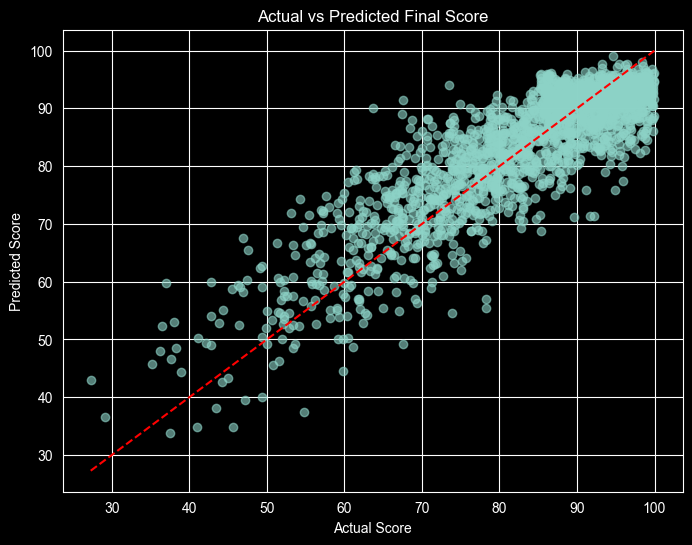

In [76]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_final, alpha=0.6)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Final Score")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.show()

După compararea tuturor algoritmilor și optimizarea hiperparametrilor, modelul final ales a fost **CatBoost Regressor**, deoarece a obținut cele mai bune rezultate de performanță.

În această etapă, modelul este evaluat pe setul de test prin:

- generarea predicțiilor numerice pentru `Final_Score`;
- compararea valorilor reale cu cele estimate;
- calcularea metricilor finale de regresie:
  - **R² Score** – proporția variației explicate de model;
  - **MAE** – eroarea medie absolută;
  - **RMSE** – eroarea pătratică medie;
- reprezentarea grafică a relației dintre valorile reale și cele prezise.

Scopul acestei secțiuni este validarea performanței finale a modelului și observarea capacității sale de generalizare pe date noi.

# 7. Concluzii finale

În acest proiect a fost abordată o problemă de regresie privind predicția scorului final al studenților pe baza unor factori academici, personali și comportamentali.

Au fost parcurse toate etapele unui pipeline complet de machine learning:
- analiza și curățarea datelor
- analiza exploratorie a datelor (EDA)
- preprocesare
- antrenarea și compararea mai multor modele de regresie
- optimizarea hiperparametrilor
- learning curves
- interpretabilitatea folosind SHAP

Modelul final selectat a fos **CatBoost Regressor**, deoarece a obținut cele mai bune rezultate după ajustarea hiperparametrilor, având cel mai ridicat scor R2 și cele mai mici erori de predicție.

Analiza SHAP a confirmat faptul că variabilele cele mai importante pentru estimarea scorului final sunt cele legate de timpul de studiu, nivelul de stres și performanțele academice anterioare.

Rezultatele obținute demonstrează că algoritmii de machine learning pot estima eficient performanța academică și pot evidenția principalii factori care influențează succesul educațional.

In [78]:
import joblib

joblib.dump(best_regression_estimators["CatBoost Regressor"], "../models/regression_model.pkl")

['models/regression_model.pkl']